# Importar Datos

In [3]:
import os
from dotenv import load_dotenv
from roboflow import Roboflow

# Carga las variables del archivo .env
load_dotenv()

# Obtiene la API Key de las variables de entorno
ROBOFLOW_KEY = os.getenv("API_ROBOFLOW")
ROBOFLOW_WORKSPACE = os.getenv("API_ROBOFLOW_WORKSPACE")
ROBOFLOW_PROJECT = os.getenv("API_ROBOFLOW_PROJECT")

if not ROBOFLOW_KEY:
    raise ValueError("No se encontró la variable de entorno 'API_ROBOFLOW'. Asegúrate de definirla en tu archivo .env")

rf = Roboflow(api_key=f"{ROBOFLOW_KEY}")
project = rf.workspace(f"{ROBOFLOW_WORKSPACE}").project(f"{ROBOFLOW_PROJECT}")
version = project.version(5)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


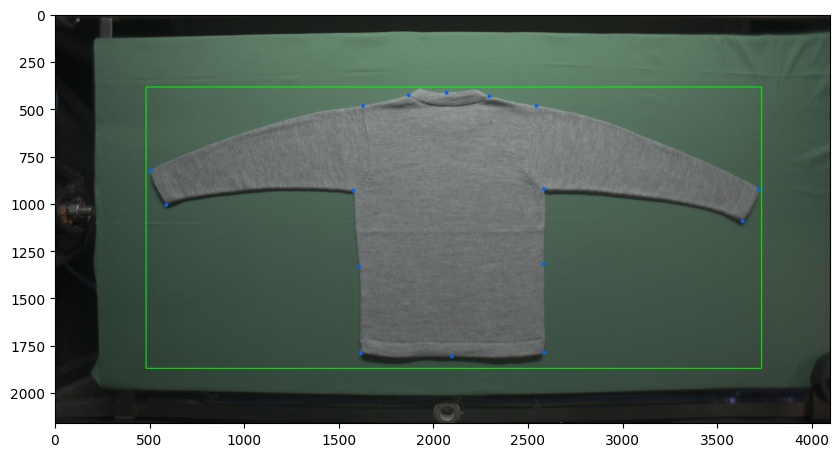

In [15]:
import os
import cv2
import matplotlib.pyplot as plt

BASE_PATH = dataset.location
imagen = "tmp__hpm12e_jpg.rf.b01a2568d574163e25ac29636e0c1863"

img_path = os.path.join(BASE_PATH, f"train", "images", f"{imagen}.jpg")
label_path = os.path.join(BASE_PATH, f"train", "labels", f"{imagen}.txt")

def verify_alignment_with_bbox(img_p, lbl_p):
    # VERIFICACIÓN DE EXISTENCIA
    if not os.path.exists(img_p):
        print(f"❌ ERROR: No se encuentra la IMAGEN en: {img_p}")
        return
    if not os.path.exists(lbl_p):
        print(f"❌ ERROR: No se encuentra el LABEL en: {lbl_p}")
        return

    # Leer imagen
    img = cv2.imread(img_p)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h_img, w_img, _ = img.shape

    with open(lbl_p, 'r') as f:
        line = f.readline().split()
        if not line: 
            print("El archivo de etiqueta está vacío")
            return

        # Dibujar BBox
        xc, yc, w, h = float(line[1]), float(line[2]), float(line[3]), float(line[4])
        x1 = int((xc - w/2) * w_img)
        y1 = int((yc - h/2) * h_img)
        x2 = int((xc + w/2) * w_img)
        y2 = int((yc + h/2) * h_img)

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
        
        # Dibujar Keypoints
        for i in range(5, len(line), 3):
            px = float(line[i]) * w_img
            py = float(line[i+1]) * h_img
            cv2.circle(img, (int(px), int(py)), 10, (0, 100, 255), -1)

    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('on')
    plt.show()

# Ejecutar
verify_alignment_with_bbox(img_path, label_path)

In [4]:
import os
import cv2
import numpy as np
from PIL import Image

def process_dataset_fixed(input_dir, output_dir, target_size):
    """
    Versión sin BiRefNet que genera el metadata_dict 
    usando los labels para encontrar el área de la prenda.
    """
    if not os.path.exists(output_dir): 
        os.makedirs(output_dir)
    
    metadata = {}
    valid_extensions = ('.jpg', '.png', '.jpeg', '.webp')
    input_label_dir = input_dir.replace("images", "labels")

    for img_name in os.listdir(input_dir):
        if not img_name.lower().endswith(valid_extensions): continue

        img_path = os.path.join(input_dir, img_name)
        img_cv = cv2.imread(img_path)
        if img_cv is None: continue
        h_orig, w_orig = img_cv.shape[:2]

        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(input_label_dir, label_name)
        if not os.path.exists(label_path): continue

        # 1. Encontrar extremos usando los labels originales para el CROP
        all_pts = []
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5: continue
                # Tomamos todos los x, y de la línea (BBox y Keypoints)
                pts = np.array(parts[1:], dtype=float).reshape(-1, 2 if len(parts[1:]) % 2 == 0 else 3)
                pts_px = pts[:, :2].copy()
                pts_px[:, 0] *= w_orig
                pts_px[:, 1] *= h_orig
                all_pts.append(pts_px)

        if not all_pts: continue
        all_pts = np.concatenate(all_pts)
        x_min_p, y_min_p = all_pts[:, 0].min(), all_pts[:, 1].min()
        x_max_p, y_max_p = all_pts[:, 0].max(), all_pts[:, 1].max()

        # 2. Definir Crop con margen (el 0.2 que usabas antes)
        bw, bh = x_max_p - x_min_p, y_max_p - y_min_p
        x_min = max(0, int(x_min_p - bw * 0.2))
        y_min = max(0, int(y_min_p - bh * 0.2))
        x_max = min(w_orig, int(x_max_p + bw * 0.2))
        y_max = min(h_orig, int(y_max_p + bh * 0.2))

        # 3. Recorte y Canvas Cuadrado
        crop = img_cv[y_min:y_max, x_min:x_max]
        ch, cw = crop.shape[:2]
        max_side = max(ch, cw)
        
        canvas = np.zeros((max_side, max_side, 3), dtype=np.uint8)
        off_x, off_y = (max_side - cw) // 2, (max_side - ch) // 2
        canvas[off_y:off_y + ch, off_x:off_x + cw] = crop
        
        # 4. Redimensionar y Guardar
        final_img = cv2.resize(canvas, (target_size, target_size), interpolation=cv2.INTER_LANCZOS4)
        cv2.imwrite(os.path.join(output_dir, img_name), final_img)
        
        # 5. Guardar METADATA (tal cual lo pedía tu función transform_labels)
        # Importante: scale debe ser respecto al max_side para que la proporción sea 1:1
        metadata[img_name] = (x_min, y_min, off_x, off_y, target_size / max_side)

    return metadata

def transform_labels_fixed(input_img_dir, input_label_dir, output_label_dir, metadata_dict, TARGET_SIZE):
    """
    Tu función original corregida para evitar el IndexError 
    y asegurar que el escalado sea perfecto.
    """
    if not os.path.exists(output_label_dir): os.makedirs(output_label_dir)

    for img_name, (x_min, y_min, off_x, off_y, scale) in metadata_dict.items():
        label_name = os.path.splitext(img_name)[0] + ".txt"
        
        orig_img_path = os.path.join(input_img_dir, img_name)
        with Image.open(orig_img_path) as temp_img:
            orig_w, orig_h = temp_img.size

        input_path = os.path.join(input_label_dir, label_name)
        output_path = os.path.join(output_label_dir, label_name)
        if not os.path.exists(input_path): continue

        with open(input_path, 'r') as f:
            lines = f.readlines()

        new_lines = []
        for line in lines:
            parts = line.split()
            if len(parts) < 5: continue
            class_id = parts[0]

            temp_kpts_x = []
            temp_kpts_y = []
            kpts_formatted = []

            # 2. Transformar Keypoints (Manejo dinámico para evitar IndexError)
            # Empezamos en 5 porque: 0:ID, 1:XC, 2:YC, 3:W, 4:H
            for i in range(5, len(parts), 3):
                if i + 1 >= len(parts): break # Seguridad contra índices fuera de rango
                
                kx_orig = float(parts[i]) * orig_w
                ky_orig = float(parts[i+1]) * orig_h
                v = parts[i+2]

                # Aplicamos la fórmula: (Punto - OrigenCrop + DesplazamientoCanvas) * (1024 / LadoMáximo)
                # Y dividimos por TARGET_SIZE para normalizar a YOLO (0-1)
                kx_final = ((kx_orig - x_min) + off_x) * scale / TARGET_SIZE
                ky_final = ((ky_orig - y_min) + off_y) * scale / TARGET_SIZE

                kx_final = max(0, min(1, kx_final))
                ky_final = max(0, min(1, ky_final))

                temp_kpts_x.append(kx_final)
                temp_kpts_y.append(ky_final)
                kpts_formatted.extend([f"{kx_final:.6f}", f"{ky_final:.6f}", v])

            if not temp_kpts_x: continue

            # 3. BBox DINÁMICO (Basado en tus Keypoints)
            xmin_kp, xmax_kp = min(temp_kpts_x), max(temp_kpts_x)
            ymin_kp, ymax_kp = min(temp_kpts_y), max(temp_kpts_y)

            margin = 0.03
            x1, y1 = max(0, xmin_kp - margin), max(0, ymin_kp - margin)
            x2, y2 = min(1, xmax_kp + margin), min(1, ymax_kp + margin)

            bbox_w, bbox_h = x2 - x1, y2 - y1
            bbox_xc, bbox_yc = x1 + (bbox_w / 2), y1 + (bbox_h / 2)

            final_parts = [class_id, f"{bbox_xc:.6f}", f"{bbox_yc:.6f}", f"{bbox_w:.6f}", f"{bbox_h:.6f}"] + kpts_formatted
            new_lines.append(" ".join(final_parts))

        with open(output_path, 'w') as f:
            f.write("\n".join(new_lines))

# --- EJECUCIÓN ---
TARGET_SIZE = 1024
INPUT_PATH = dataset.location
OUTPUT_BASE = r"C:\Users\USER\Desktop\clothes-failures-detection"

for split in ["train", "valid","test"]:
    img_in = os.path.join(INPUT_PATH, split, "images")
    lab_in = os.path.join(INPUT_PATH, split, "labels")
    img_out = os.path.join(OUTPUT_BASE, split, "images")
    lab_out = os.path.join(OUTPUT_BASE, split, "labels")

    if os.path.exists(img_in):
        print(f"Procesando imágenes de {split}...")
        meta = process_dataset_fixed(img_in, img_out, TARGET_SIZE)
        
        print(f"Transformando etiquetas de {split}...")
        transform_labels_fixed(img_in, lab_in, lab_out, meta, TARGET_SIZE)

Procesando imágenes de train...
Transformando etiquetas de train...
Procesando imágenes de valid...
Transformando etiquetas de valid...
Procesando imágenes de test...
Transformando etiquetas de test...


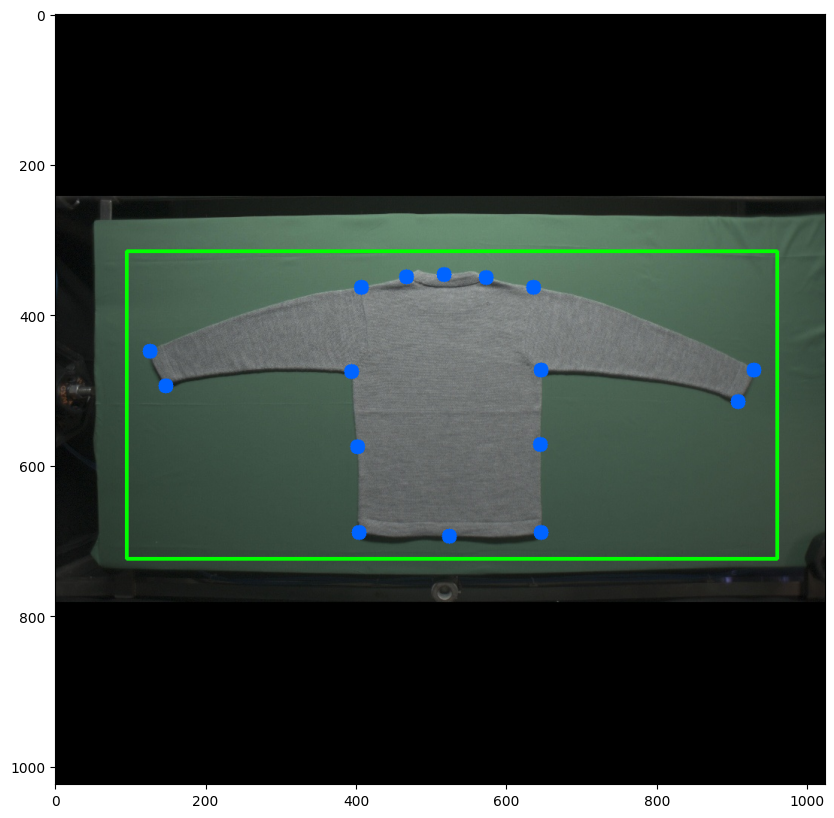

In [23]:
import os
import cv2
import matplotlib.pyplot as plt

#C:\Users\USER\Desktop\clothes-failures-detection\train\images\tmp__hpm12e_jpg.rf.b01a2568d574163e25ac29636e0c1863.jpg

BASE_PATH = r'C:\Users\USER\Desktop\clothes-failures-detection'
imagen = "tmp__hpm12e_jpg.rf.b01a2568d574163e25ac29636e0c1863"

img_path = os.path.join(BASE_PATH, f"train", "images", f"{imagen}.jpg")
label_path = os.path.join(BASE_PATH, f"train", "labels", f"{imagen}.txt")

def verify_alignment_with_bbox(img_p, lbl_p):
    # VERIFICACIÓN DE EXISTENCIA
    if not os.path.exists(img_p):
        print(f"❌ ERROR: No se encuentra la IMAGEN en: {img_p}")
        return
    if not os.path.exists(lbl_p):
        print(f"❌ ERROR: No se encuentra el LABEL en: {lbl_p}")
        return

    # Leer imagen
    img = cv2.imread(img_p)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h_img, w_img, _ = img.shape

    with open(lbl_p, 'r') as f:
        line = f.readline().split()
        if not line: 
            print("El archivo de etiqueta está vacío")
            return

        # Dibujar BBox
        xc, yc, w, h = float(line[1]), float(line[2]), float(line[3]), float(line[4])
        x1 = int((xc - w/2) * w_img)
        y1 = int((yc - h/2) * h_img)
        x2 = int((xc + w/2) * w_img)
        y2 = int((yc + h/2) * h_img)

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
        
        # Dibujar Keypoints
        for i in range(5, len(line), 3):
            px = float(line[i]) * w_img
            py = float(line[i+1]) * h_img
            cv2.circle(img, (int(px), int(py)), 10, (0, 100, 255), -1)

    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('on')
    plt.show()

# Ejecutar
verify_alignment_with_bbox(img_path, label_path)

# Aumento de data

In [ ]:
import albumentations as A
import cv2
import os
import numpy as np

# Configuración de rutas
BASE_PATH = r'C:\Users\USER\Desktop\clothes-failures-detection'
INPUT_IMG_AUG = os.path.join(BASE_PATH, "train", "images")
INPUT_LBL_AUG = os.path.join(BASE_PATH, "train", "labels")
OUTPUT_IMG_AUG = os.path.join(BASE_PATH, "train_aug", "images")
OUTPUT_LBL_AUG = os.path.join(BASE_PATH, "train_aug", "labels")

# Color de tu mesa verde (ajusta según el RGB real de tus fotos)
MESA_VERDE_RGB = [60, 100, 60] 

# 1. Definir el Pipeline Robusto para Metrología e Independencia de Color
transform = A.Compose([
    # Robustez ante colores (hace que la IA aprenda formas, no colores)
    A.ToGray(p=0.2),
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.4),
    
    # Iluminación industrial
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.4),
    
    # CRÍTICO: Traslación y Rotación para corregir el error de los puños en los bordes
    A.ShiftScaleRotate(
        shift_limit=0.08,    # Mueve la prenda para verla en diferentes zonas de la lente
        scale_limit=0.15,    # Simula variaciones de tamaño de prenda
        rotate_limit=15, 
        border_mode=cv2.BORDER_CONSTANT, 
        value=MESA_VERDE_RGB, # Rellena con el color de la mesa, no con negro
        interpolation=cv2.INTER_LANCZOS4, # Máxima nitidez en bordes
        p=0.8
    ),
    
    # Ruido sensor suave
    A.GaussNoise(std_range=(0.01, 0.02), p=0.2),
    
], keypoint_params=A.KeypointParams(format='xy', remove_invisible=True))

def augment_dataset(img_dir, label_dir, output_img_dir, output_label_dir, n_variants=5):
    if not os.path.exists(output_img_dir): os.makedirs(output_img_dir)
    if not os.path.exists(output_label_dir): os.makedirs(output_label_dir)

    img_files = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))]
    print(f"Iniciando aumento de {len(img_files)} imágenes...")

    for img_name in img_files:
        img_path = os.path.join(img_dir, img_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w, _ = image.shape

        label_path = os.path.join(label_dir, os.path.splitext(img_name)[0] + ".txt")
        if not os.path.exists(label_path): continue

        with open(label_path, 'r') as f:
            line = f.readline().split()
            class_id = line[0]
            kpts = []
            visibilities = []
            for i in range(5, len(line), 3):
                kpts.append([float(line[i]) * w, float(line[i+1]) * h])
                visibilities.append(line[i+2])

        # Generar variantes válidas
        v = 0
        intentos = 0
        while v < n_variants and intentos < (n_variants * 3):
            intentos += 1
            transformed = transform(image=image, keypoints=kpts)
            t_image = transformed['image']
            t_kpts = transformed['keypoints']

            # FILTRO DE SEGURIDAD: Solo guardamos si todos los puntos están dentro
            if len(t_kpts) < len(kpts):
                continue 

            v += 1
            new_name = f"aug_{v}_{img_name}"

            # Guardar Imagen (BGR para OpenCV)
            cv2.imwrite(os.path.join(output_img_dir, new_name), cv2.cvtColor(t_image, cv2.COLOR_RGB2BGR))

            # Procesar Label
            t_kpts_norm = np.array(t_kpts) / [w, h]
            
            # Recalcular BBox dinámico basado en los puntos transformados
            x_min, y_min = np.min(t_kpts_norm, axis=0)
            x_max, y_max = np.max(t_kpts_norm, axis=0)
            
            margin = 0.03
            bx1, by1 = max(0, x_min - margin), max(0, y_min - margin)
            bx2, by2 = min(1, x_max + margin), min(1, y_max + margin)
            bw, bh = bx2 - bx1, by2 - by1
            bcx, bcy = bx1 + bw/2, by1 + bh/2

            # Formatear línea final de YOLO Pose
            new_parts = [class_id, f"{bcx:.6f}", f"{bcy:.6f}", f"{bw:.6f}", f"{bh:.6f}"]
            for i, (kx, ky) in enumerate(t_kpts_norm):
                new_parts.extend([f"{kx:.6f}", f"{ky:.6f}", visibilities[i]])

            with open(os.path.join(output_label_dir, os.path.splitext(new_name)[0] + ".txt"), 'w') as f:
                f.write(" ".join(new_parts))

    print(f"Dataset aumentado con éxito. Total imágenes: {len(img_files) * n_variants}")

if __name__ == '__main__':
    augment_dataset(INPUT_IMG_AUG, INPUT_LBL_AUG, OUTPUT_IMG_AUG, OUTPUT_LBL_AUG, n_variants=5)

In [25]:
import albumentations as A
import cv2
import os
import numpy as np
BASE_PATH = r'C:\Users\USER\Desktop\clothes-failures-detection'

INPUT_IMG_AUG = os.path.join(BASE_PATH, f"train", "images")
INPUT_LBL_AUG = os.path.join(BASE_PATH, f"train", "labels")
OUTPUT_IMG_AUG = os.path.join(BASE_PATH, f"train_aug", "images")
OUTPUT_LBL_AUG = os.path.join(BASE_PATH, f"train_aug", "labels")

# 1. Definir el Pipeline (Seguro para Metrología)
transform = A.Compose([
    #A.HorizontalFlip(p=0.5),
    # Bajamos un poco el contraste para no "quemar" los bordes
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.4),
    A.Rotate(
        limit=15,
        border_mode=cv2.BORDER_CONSTANT,
        fill_value=0,
        interpolation=cv2.INTER_LANCZOS4, # CRÍTICO: Mantiene el borde nítido
        p=0.5
    ),
    # GaussNoise casi imperceptible para no deformar el borde
    A.GaussNoise(std_range=(0.01, 0.02), p=0.2),
], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

def augment_dataset(img_dir, label_dir, output_img_dir, output_label_dir, n_variants=5):
    if not os.path.exists(output_img_dir): os.makedirs(output_img_dir)
    if not os.path.exists(output_label_dir): os.makedirs(output_label_dir)

    img_files = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))]

    print(f"Iniciando aumento de {len(img_files)} imágenes...")

    for img_name in img_files:
        # Cargar imagen
        img_path = os.path.join(img_dir, img_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w, _ = image.shape

        # Cargar etiquetas (Keypoints)
        label_path = os.path.join(label_dir, os.path.splitext(img_name)[0] + ".txt")
        if not os.path.exists(label_path): continue

        with open(label_path, 'r') as f:
            line = f.readline().split()
            class_id = line[0]
            # Extraer solo x, y de los keypoints (ignorando visibilidad temporalmente)
            kpts = []
            visibilities = []
            for i in range(5, len(line), 3):
                kpts.append([float(line[i]) * w, float(line[i+1]) * h])
                visibilities.append(line[i+2])

        # Generar variantes
        for v in range(n_variants):
            transformed = transform(image=image, keypoints=kpts)
            t_image = transformed['image']
            t_kpts = transformed['keypoints']

            # Nombre de archivo único
            new_name = f"aug_{v}_{img_name}"

            # Guardar Imagen
            cv2.imwrite(os.path.join(output_img_dir, new_name), cv2.cvtColor(t_image, cv2.COLOR_RGB2BGR))

            # Guardar Label (con el BBox recalculado para la nueva posición)
            t_kpts_np = np.array(t_kpts)
            # Normalizar de nuevo
            t_kpts_norm = t_kpts_np / [w, h]

            # Recalcular BBox dinámico para la variante aumentada
            x_min, y_min = np.min(t_kpts_norm, axis=0)
            x_max, y_max = np.max(t_kpts_norm, axis=0)

            margin = 0.03
            bx1, by1 = max(0, x_min - margin), max(0, y_min - margin)
            bx2, by2 = min(1, x_max + margin), min(1, y_max + margin)

            bw, bh = bx2 - bx1, by2 - by1
            bcx, bcy = bx1 + bw/2, by1 + bh/2

            # Formatear línea final
            new_parts = [class_id, f"{bcx:.6f}", f"{bcy:.6f}", f"{bw:.6f}", f"{bh:.6f}"]
            for i, (kx, ky) in enumerate(t_kpts_norm):
                new_parts.extend([f"{kx:.6f}", f"{ky:.6f}", visibilities[i]])

            with open(os.path.join(output_label_dir, os.path.splitext(new_name)[0] + ".txt"), 'w') as f:
                f.write(" ".join(new_parts))

    print(f"¡Hecho! Dataset multiplicado. Ahora tienes aproximadamente {len(img_files) * n_variants} imágenes.")

# Ejecutar (Aumentar x5)
augment_dataset(INPUT_IMG_AUG, INPUT_LBL_AUG, OUTPUT_IMG_AUG, OUTPUT_LBL_AUG, n_variants=5)

Argument(s) 'fill_value' are not valid for transform Rotate


Iniciando aumento de 96 imágenes...
¡Hecho! Dataset multiplicado. Ahora tienes aproximadamente 480 imágenes.


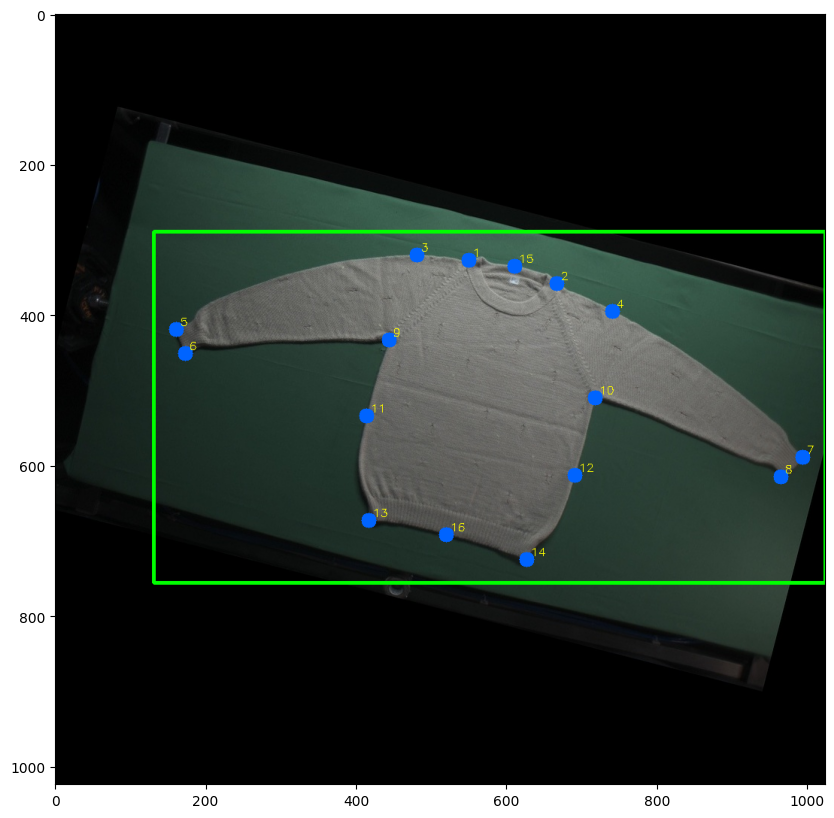

In [31]:
import os
import cv2
import matplotlib.pyplot as plt

#C:\Users\USER\Desktop\clothes-failures-detection\train\images\tmp__hpm12e_jpg.rf.b01a2568d574163e25ac29636e0c1863.jpg

BASE_PATH = r'C:\Users\USER\Desktop\clothes-failures-detection'
imagen = "aug_0_tmp6ph1bll2_jpg.rf.c2edbd5458fb9cff2a1c2168789ff229"

img_path = os.path.join(BASE_PATH, f"train_aug", "images", f"{imagen}.jpg")
label_path = os.path.join(BASE_PATH, f"train_aug", "labels", f"{imagen}.txt")

def verify_alignment_with_bbox(img_p, lbl_p):
    # VERIFICACIÓN DE EXISTENCIA
    if not os.path.exists(img_p):
        print(f"❌ ERROR: No se encuentra la IMAGEN en: {img_p}")
        return
    if not os.path.exists(lbl_p):
        print(f"❌ ERROR: No se encuentra el LABEL en: {lbl_p}")
        return

    # Leer imagen
    img = cv2.imread(img_p)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h_img, w_img, _ = img.shape

    with open(lbl_p, 'r') as f:
        line = f.readline().split()
        if not line: 
            print("El archivo de etiqueta está vacío")
            return

        # Dibujar BBox
        xc, yc, w, h = float(line[1]), float(line[2]), float(line[3]), float(line[4])
        x1 = int((xc - w/2) * w_img)
        y1 = int((yc - h/2) * h_img)
        x2 = int((xc + w/2) * w_img)
        y2 = int((yc + h/2) * h_img)

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
        
        # Dibujar Keypoints
        for i in range(5, len(line), 3):
            px = float(line[i]) * w_img
            py = float(line[i+1]) * h_img
            cv2.circle(img, (int(px), int(py)), 10, (0, 100, 255), -1)
            cv2.putText(img, str(i//3), (int(px)+5, int(py)-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)

    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('on')
    plt.show()

# Ejecutar
verify_alignment_with_bbox(img_path, label_path)

# Generar Data YAML

In [5]:
import yaml
import os

BASE_PATH = r'C:\Users\USER\Desktop\clothes-failures-detection'
TARGET_SIZE = 1024

# Corregimos los nombres de las rutas para el YAML
# YOLO usa la ruta 'path' como raíz y luego concatena 'train' y 'val'
# Es mejor usar rutas relativas dentro del YAML o la ruta absoluta completa.

# Mapa de simetría (se mantiene igual)
flip_idx = [1, 0, 3, 2, 6, 7, 4, 5, 9, 8, 11, 10, 13, 12, 14, 15]

data_config = {
    # 'path' debe ser la carpeta raíz de tu proyecto
    'path': BASE_PATH, 
    
    # Rutas relativas desde 'path'
    'train': 'train_aug/images',
    'val': 'valid/images',
    'test': 'test/images',
    
    'nc': 1,
    'names': {0: 'chompa'}, # Formato diccionario es más robusto para YOLO
    
    # Keypoints: 16 puntos, cada uno con [x, y, v]
    'kpt_shape': [16, 3], 
    
    # Mapa de simetría para aumentación automática durante entrenamiento
    'flip_idx': flip_idx
}

# Guardar el archivo en la raíz del proyecto
yaml_path = os.path.join(BASE_PATH, 'chompa_pose.yaml')

with open(yaml_path, 'w') as f:
    # default_flow_style=False genera un YAML legible (vertical)
    # sort_keys=False mantiene el orden que definimos
    yaml.dump(data_config, f, default_flow_style=False, sort_keys=False)

print(f"✅ 'chompa_pose.yaml' creado en: {yaml_path}")
print(f"--- Configuración local de Windows lista ---")

✅ 'chompa_pose.yaml' creado en: C:\Users\USER\Desktop\clothes-failures-detection\chompa_pose.yaml
--- Configuración local de Windows lista ---


# Transfer Learning

In [1]:
import torch
from ultralytics import YOLO

print(f"✓ PyTorch {torch.__version__} con CUDA {torch.version.cuda}")
print(f"✓ GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

# Test básico de tensor en GPU
if torch.cuda.is_available():
    x = torch.randn(2, 3).cuda()
    y = x * 2
    print(f"✓ Operación CUDA exitosa: {y.device}")

# Test de carga de modelo YOLO (sin entrenar)
model = YOLO('yolo11m-pose.pt')
print(f"✓ Modelo YOLO cargado: {model.task}")

✓ PyTorch 2.11.0+cu128 con CUDA 12.8
✓ GPU: NVIDIA GeForce RTX 5060
✓ Operación CUDA exitosa: cuda:0
✓ Modelo YOLO cargado: pose


In [2]:
import torch
from ultralytics import YOLO
import os
import gc

def clear_gpu():
    torch.cuda.empty_cache()
    gc.collect()
    # En la serie 50, a veces es mejor dejar que Windows gestione los segmentos solo
    if "PYTORCH_CUDA_ALLOC_CONF" in os.environ:
        del os.environ["PYTORCH_CUDA_ALLOC_CONF"]

if __name__ == '__main__':
    clear_gpu()

    # 1. Cargamos el modelo MEDIUM
    model = YOLO('yolo11m-pose.pt')

    # 2. Entrenamiento v1_sin_segmentacion
    results = model.train(
        data='chompa_pose.yaml',
        imgsz=1024,
        epochs=150,
        batch=4, 
        
        # --- ESTABILIDAD PARA RTX 5060 ---
        amp=False,              # <--- SOLUCIÓN AL ERROR DE KERNEL: Desactiva precisión mixta
        optimizer='AdamW',
        
        # --- WINDOWS ---
        workers=0,
        cache=False,
        
        # --- PRECISIÓN PARA PUÑOS ---
        lr0=0.001,
        pose=100.0,
        kobj=20.0,
        
        # --- AUGMENTATION YOLO ---
        fliplr=0.5,
        mosaic=0.0,
        hsv_v=0.4,
        hsv_s=0.4,
        
        # --- CONFIG ---
        patience=50,
        project='metrologia_chompas',
        name='v1_sin_segmentacion',
        device=0,
        plots=True
    )

New https://pypi.org/project/ultralytics/8.4.37 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.241  Python-3.12.12 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060, 8151MiB)
engine\trainer: agnostic_nms=False, amp=False, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=chompa_pose.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.4, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=20.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-pose.pt, momentum=0.937, mosaic=0.0, multi_scale=False, name=v1_sin_segmentacion3, nbs=64, 

In [2]:
import torch
from ultralytics import YOLO
import os
import gc

def clear_gpu():
    torch.cuda.empty_cache()
    gc.collect()
    # Forzamos a que PyTorch no sea tan rígido con la memoria en la serie 50
    os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

if __name__ == '__main__':
    clear_gpu()

    # 1. Cargamos el modelo MEDIUM
    model = YOLO('yolo11m-pose.pt')

    results = model.train(
        data='chompa_pose.yaml',
        imgsz=1024,
        rect=True,
        epochs=200,
        batch=2,
        amp=False,
        half=True,              # <--- AGREGA ESTO: Reduce el consumo de VRAM a la mitad
        
        # --- PESOS DE METROLOGÍA ---
        lr0=0.001,
        pose=150.0,             
        kobj=2.0,
        workers=0,

        # --- AUGMENTATION ---
        fliplr=0.5,
        scale=0.5,
        translate=0.1,
        mosaic=0.0,
        hsv_v=0.4,
        hsv_s=0.4,
        
        # --- CONFIG ---
        optimizer='AdamW',
        project='metrologia_chompas',
        name='v2_rect_proporcional',
        device=0
    )

New https://pypi.org/project/ultralytics/8.4.38 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.241  Python-3.12.12 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060, 8151MiB)
engine\trainer: agnostic_nms=False, amp=False, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=chompa_pose.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=True, hsv_h=0.015, hsv_s=0.4, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=2.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-pose.pt, momentum=0.937, mosaic=0.0, multi_scale=False, name=v2_rect_proporcional2, nbs=64, n

# Resultados

C:\Users\USER\Desktop\clothes-failures-detection\metrologia_chompas\v1_sin_segmentacion3\results.png


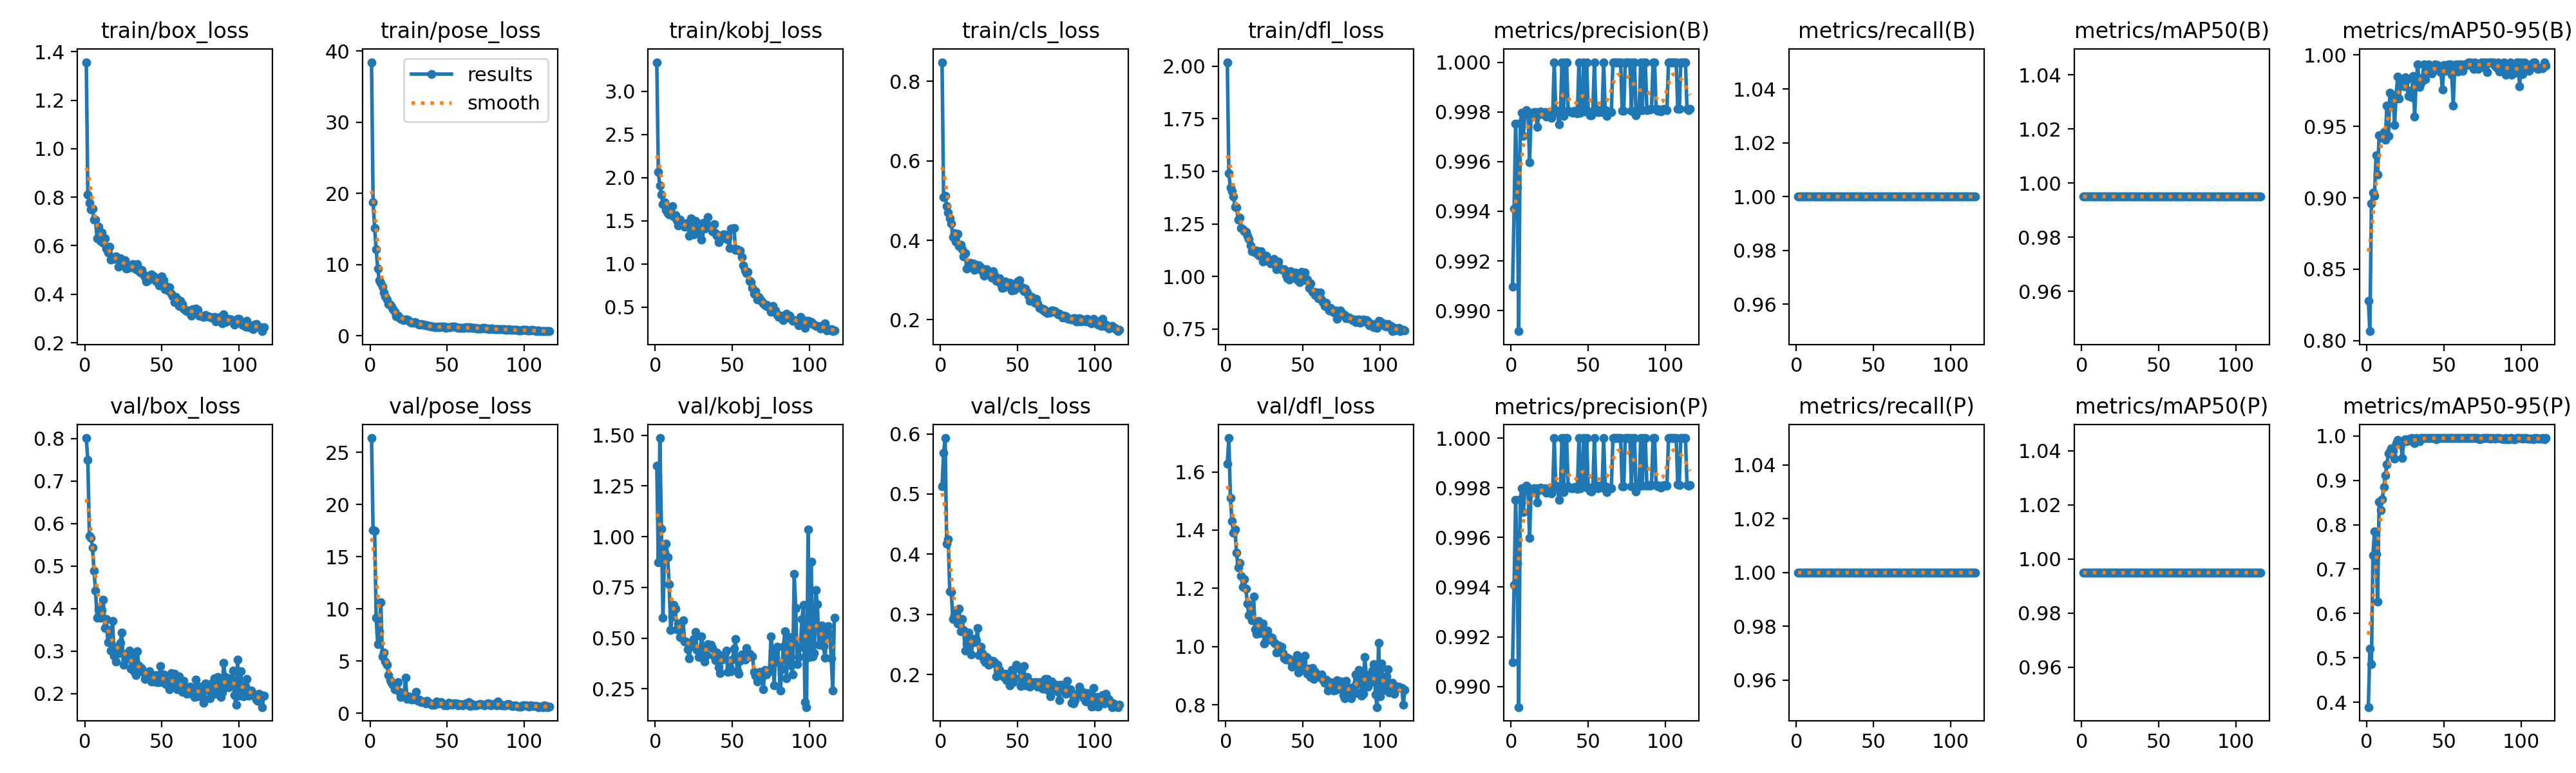

In [1]:
from IPython.display import Image
import os
modelo = 'v1_sin_segmentacion3'

BASE_PATH = r'C:\Users\USER\Desktop\clothes-failures-detection\metrologia_chompas'
TARGET_SIZE = 1024

path_resultados = os.path.join(BASE_PATH, modelo, "results.png")
print(path_resultados)
if os.path.exists(path_resultados):
    display(Image(filename=path_resultados, width=800))
else:
    print("El archivo aún no se ha generado. Espera a que termine al menos la primera época.")

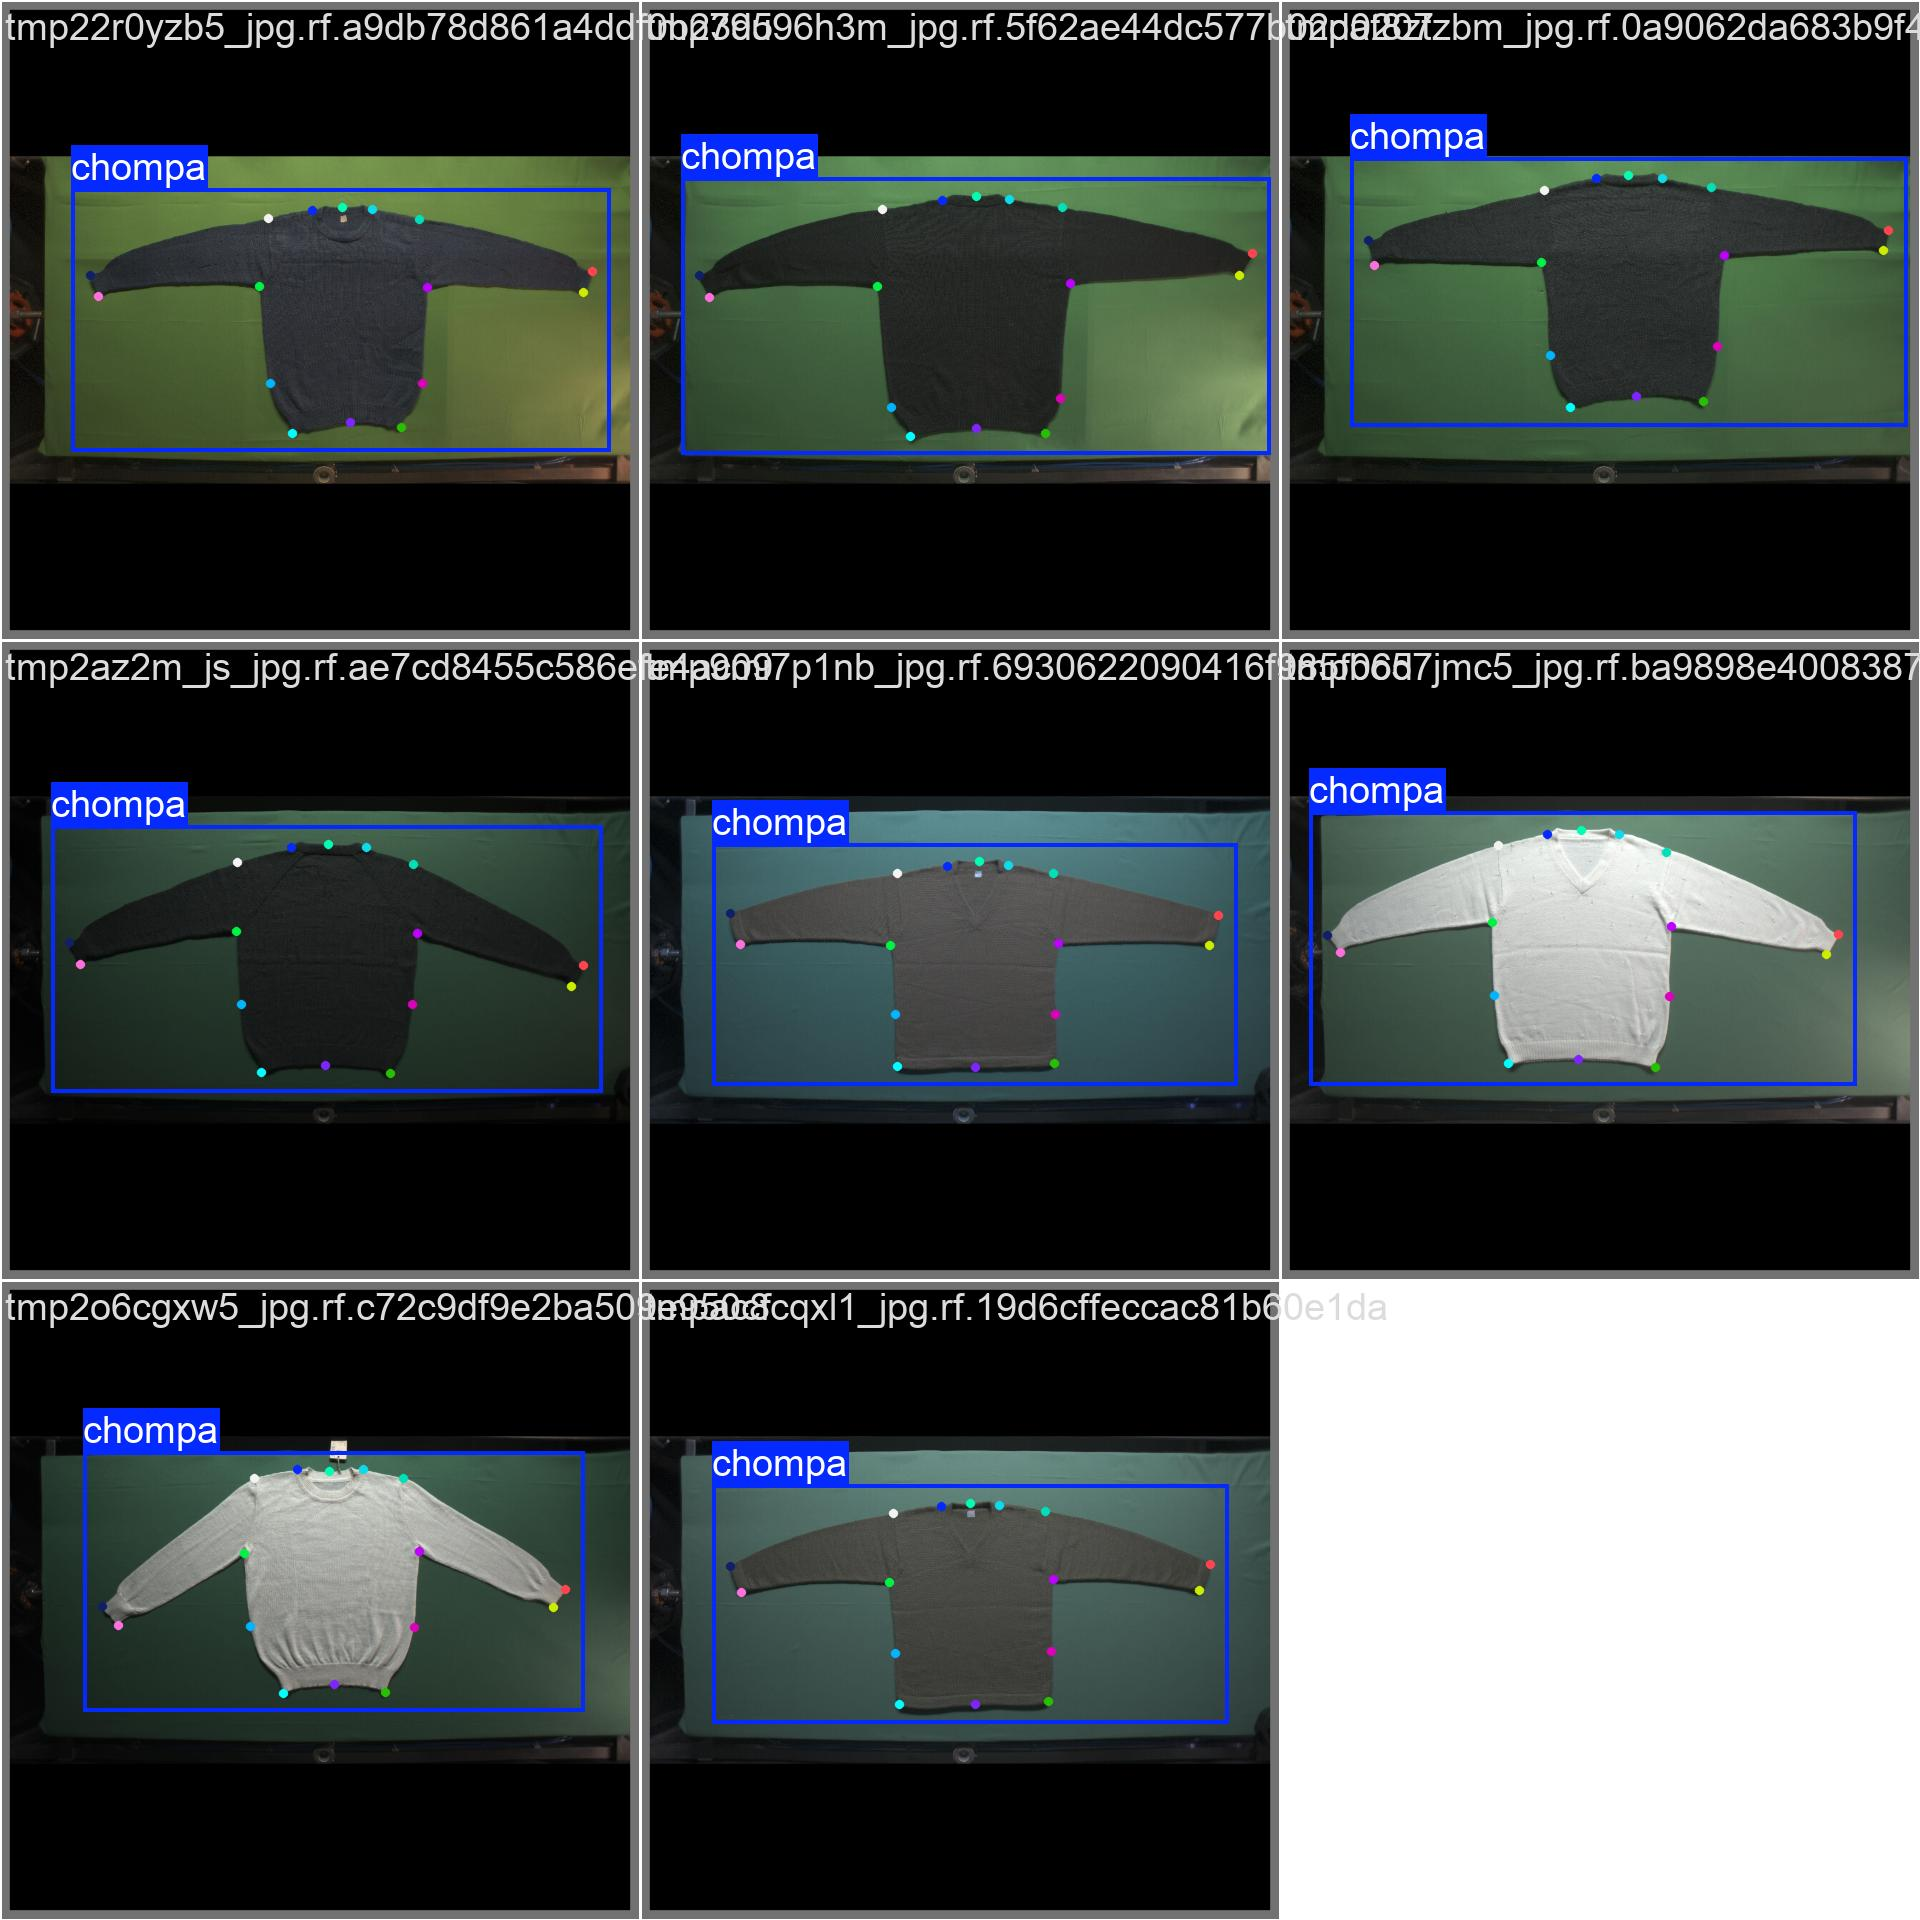

In [2]:
from IPython.display import Image
import os
BASE_PATH = r'C:\Users\USER\Desktop\clothes-failures-detection\metrologia_chompas'
TARGET_SIZE = 1024

path_resultados = os.path.join(BASE_PATH, modelo, "val_batch0_labels.jpg")

if os.path.exists(path_resultados):
    display(Image(filename=path_resultados, width=800))
else:
    print("El archivo aún no se ha generado. Espera a que termine al menos la primera época.")

In [3]:
from ultralytics import YOLO

model = YOLO("best.pt")

metrics = model.val(data="chompa_pose.yaml", split="test")

Ultralytics 8.3.241  Python-3.12.12 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060, 8151MiB)
YOLO11m-pose summary (fused): 134 layers, 20,888,419 parameters, 0 gradients, 71.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 258.3130.0 MB/s, size: 116.9 KB)
val: Scanning C:\Users\USER\Desktop\clothes-failures-detection\test\labels.cache... 11 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 11/11  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.8s/it 1.8s
                   all         11         11          1          1      0.995      0.995          1          1      0.995      0.995
Speed: 3.0ms preprocess, 28.0ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to C:\Users\USER\Desktop\clothes-failures-detection\runs\pose\val3
